In [1]:
# ==========================================
# Step 1 : Import Libraries
# ==========================================

import os
import pandas as pd

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
/home/guest/Desktop/sarvesh


In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [14]:
ratings = pd.read_csv(
    "sarvesh_kr_Recommendation-System/ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [15]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [16]:
ratings.shape

(100000, 4)

In [17]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [18]:
ratings.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

In [19]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


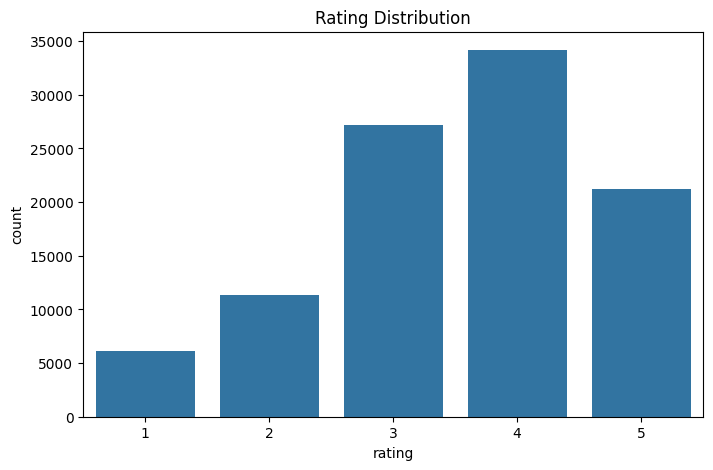

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="rating",
    data=ratings
)

plt.title("Rating Distribution")
plt.show()

# Exploratory Data Analysis (EDA)

In this section, we explore the MovieLens 100K dataset to understand its structure, user behavior, movie popularity, and rating patterns before building the recommendation system.

In [22]:
# ============================================
# Basic Dataset Statistics
# ============================================

print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Total Ratings : {len(ratings):,}")

print(f"Unique Users : {ratings['user_id'].nunique():,}")

print(f"Unique Movies : {ratings['movie_id'].nunique():,}")

print(f"Average Rating : {ratings['rating'].mean():.2f}")

print(f"Highest Rating : {ratings['rating'].max()}")

print(f"Lowest Rating : {ratings['rating'].min()}")

DATASET OVERVIEW
Total Ratings : 100,000
Unique Users : 943
Unique Movies : 1,682
Average Rating : 3.53
Highest Rating : 5
Lowest Rating : 1


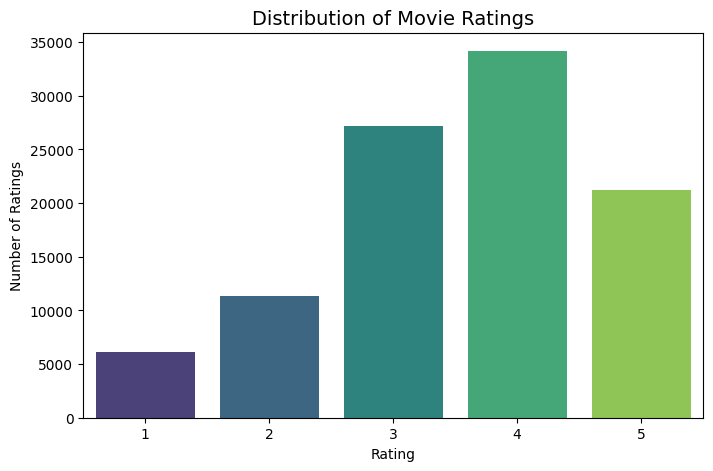

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=ratings,
    x="rating",
    palette="viridis"
)

plt.title("Distribution of Movie Ratings", fontsize=14)

plt.xlabel("Rating")

plt.ylabel("Number of Ratings")

plt.show()

## Observation

Most ratings are between **3 and 5**, indicating that users generally provide positive feedback. Very few ratings are 1, suggesting users tend to rate movies they enjoy rather than movies they dislike.

In [24]:
user_activity = ratings.groupby("user_id")["rating"].count()

user_activity = user_activity.sort_values(ascending=False)

user_activity.head(10)

user_id
405    737
655    685
13     636
450    540
276    518
416    493
537    490
303    484
234    480
393    448
Name: rating, dtype: int64

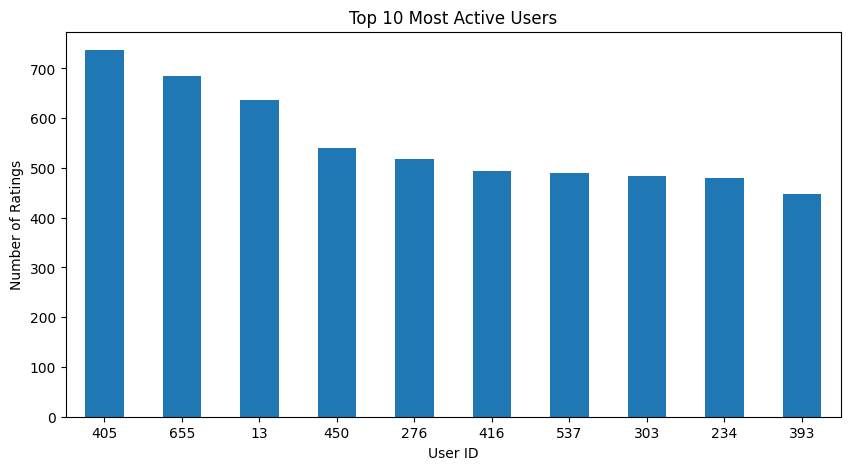

In [25]:
plt.figure(figsize=(10,5))

user_activity.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Most Active Users")

plt.xlabel("User ID")

plt.ylabel("Number of Ratings")

plt.xticks(rotation=0)

plt.show()

## Observation

A small number of users contribute a large number of ratings. Such highly active users are valuable for collaborative filtering because they provide richer preference information.

In [26]:
ratings_per_user = ratings.groupby("user_id").size()

ratings_per_user.describe()

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64

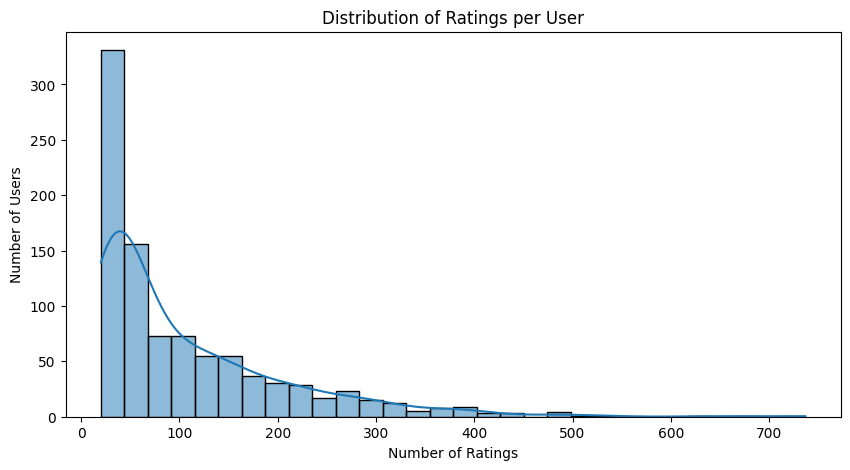

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    ratings_per_user,
    bins=30,
    kde=True
)

plt.title("Distribution of Ratings per User")

plt.xlabel("Number of Ratings")

plt.ylabel("Number of Users")

plt.show()


## Observation

- The dataset contains 100,000 user-movie ratings from 943 users on 1,682 movies.
- Ratings range from 1 to 5, with an average rating of 3.53.
- User activity is highly uneven. While the average user has rated around 106 movies, the median is only 65, indicating a right-skewed distribution.
- A few highly active users contribute hundreds of ratings, making them valuable for collaborative filtering approaches.


# Movie Information Analysis

In this section, we load movie metadata, merge it with the ratings dataset, and analyze movie popularity and average ratings.

In [28]:
# ============================================
# Load Movie Information
# ============================================

movies = pd.read_csv(
    "sarvesh_kr_Recommendation-System/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1],
    names=["movie_id", "movie_title"]
)

print("Movie dataset loaded successfully.")

Movie dataset loaded successfully.


In [29]:
movies.head()

,movie_id,movie_title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [30]:
movies.tail()

,movie_id,movie_title
1677,1678,Mat' i syn (1997)
1678,1679,B. Monkey (1998)
1679,1680,Sliding Doors (1998)
1680,1681,You So Crazy (1994)
1681,1682,Scream of Stone (Schrei aus Stein) (1991)


In [31]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   movie_id     1682 non-null   int64
 1   movie_title  1682 non-null   str  
dtypes: int64(1), str(1)
memory usage: 65.0 KB


In [32]:
movie_ratings = pd.merge(
    ratings,
    movies,
    on="movie_id"
)

movie_ratings.head()

,user_id,movie_id,rating,timestamp,movie_title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [33]:
movie_ratings.shape

(100000, 5)

In [34]:
movie_popularity = (
    movie_ratings
    .groupby("movie_title")["rating"]
    .count()
    .sort_values(ascending=False)
)

movie_popularity.head(10)

movie_title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: rating, dtype: int64

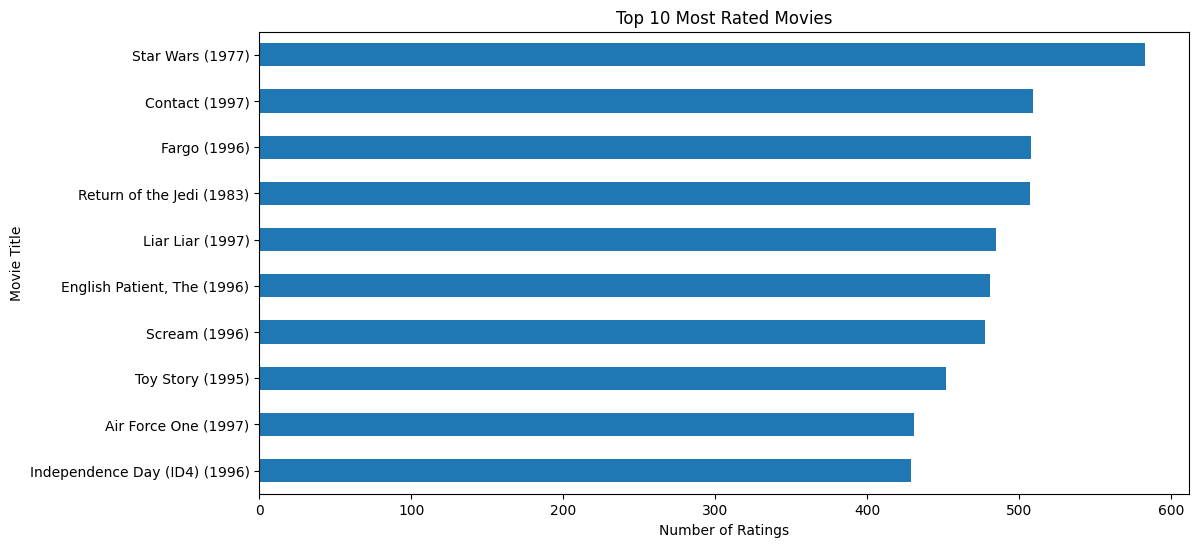

In [35]:
plt.figure(figsize=(12,6))

movie_popularity.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Most Rated Movies")

plt.xlabel("Number of Ratings")

plt.ylabel("Movie Title")

plt.show()

In [36]:
movie_average = (
    movie_ratings
    .groupby("movie_title")["rating"]
    .mean()
    .sort_values(ascending=False)
)

movie_average.head(10)

movie_title
Aiqing wansui (1994)                                 5.0
Entertaining Angels: The Dorothy Day Story (1996)    5.0
Santa with Muscles (1996)                            5.0
Prefontaine (1997)                                   5.0
They Made Me a Criminal (1939)                       5.0
Saint of Fort Washington, The (1993)                 5.0
Great Day in Harlem, A (1994)                        5.0
Star Kid (1997)                                      5.0
Marlene Dietrich: Shadow and Light (1996)            5.0
Someone Else's America (1995)                        5.0
Name: rating, dtype: float64

## Observation

- Movie popularity varies significantly across the dataset.
- Some movies receive hundreds of ratings, while many receive very few.
- A high average rating does not necessarily indicate a better movie if it is based on only a small number of ratings.
- In recommendation systems, both **average rating** and **rating count** should be considered when ranking movies.

In [37]:
movie_stats = movie_ratings.groupby("movie_title").agg(
    Average_Rating=("rating", "mean"),
    Number_of_Ratings=("rating", "count")
)

movie_stats.head()

,Average_Rating,Number_of_Ratings
movie_title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


In [38]:
movie_stats.sort_values(
    by="Number_of_Ratings",
    ascending=False
).head(10)

,Average_Rating,Number_of_Ratings
movie_title,,
Star Wars (1977),4.358491,583
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485
"English Patient, The (1996)",3.656965,481
Scream (1996),3.441423,478
Toy Story (1995),3.878319,452
Air Force One (1997),3.631090,431


In [39]:
movie_stats.sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

,Average_Rating,Number_of_Ratings
movie_title,,
Aiqing wansui (1994),5.0,1
Entertaining Angels: The Dorothy Day Story (1996),5.0,1
Santa with Muscles (1996),5.0,2
Prefontaine (1997),5.0,3
They Made Me a Criminal (1939),5.0,1
"Saint of Fort Washington, The (1993)",5.0,2
"Great Day in Harlem, A (1994)",5.0,1
Star Kid (1997),5.0,3
Marlene Dietrich: Shadow and Light (1996),5.0,1


In [40]:
movie_stats[
    movie_stats["Number_of_Ratings"] >= 100
].sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

,Average_Rating,Number_of_Ratings
movie_title,,
"Close Shave, A (1995)",4.491071,112
Schindler's List (1993),4.466443,298
"Wrong Trousers, The (1993)",4.466102,118
Casablanca (1942),4.456790,243
"Shawshank Redemption, The (1994)",4.445230,283
Rear Window (1954),4.387560,209
"Usual Suspects, The (1995)",4.385768,267
Star Wars (1977),4.358491,583
12 Angry Men (1957),4.344000,125


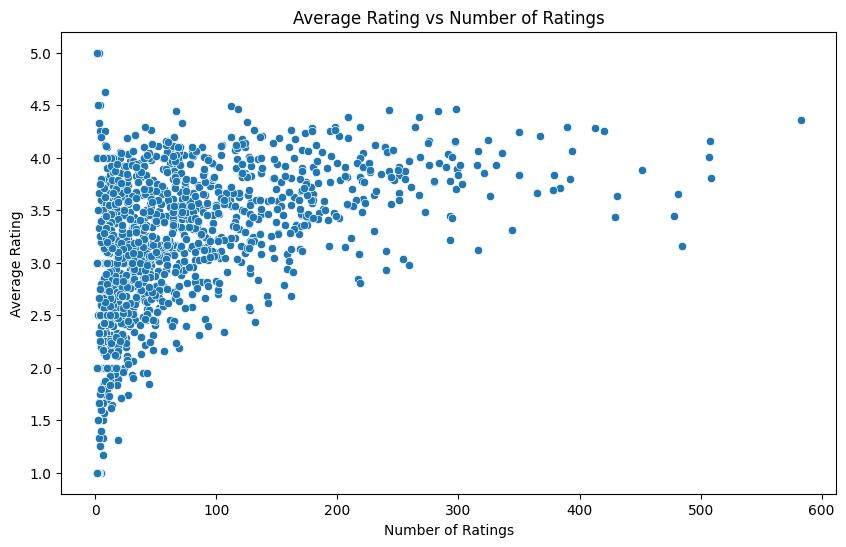

In [41]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=movie_stats,
    x="Number_of_Ratings",
    y="Average_Rating"
)

plt.title("Average Rating vs Number of Ratings")

plt.xlabel("Number of Ratings")

plt.ylabel("Average Rating")

plt.show()

## Observation

- Many movies achieve a perfect average rating of 5.0 simply because they have very few ratings.
- Considering only the average rating can produce misleading recommendations.
- Combining average rating with the number of ratings provides a more reliable measure of movie quality.
- This insight motivates the use of popularity thresholds and weighted ranking in recommendation systems.

In [42]:
movie_stats.head()

,Average_Rating,Number_of_Ratings
movie_title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


In [43]:
movie_stats.describe()

,Average_Rating,Number_of_Ratings
count,1664.000000,1664.000000
mean,3.077018,60.096154
std,0.780418,80.956484
min,1.000000,1.000000
25%,2.665094,7.000000
50%,3.162132,27.000000
75%,3.651808,80.250000
max,5.000000,583.000000


In [44]:
top_rated_movies = (
    movie_stats[movie_stats["Number_of_Ratings"] >= 100]
    .sort_values(
        by="Average_Rating",
        ascending=False
    )
)

top_rated_movies.head(10)

,Average_Rating,Number_of_Ratings
movie_title,,
"Close Shave, A (1995)",4.491071,112
Schindler's List (1993),4.466443,298
"Wrong Trousers, The (1993)",4.466102,118
Casablanca (1942),4.456790,243
"Shawshank Redemption, The (1994)",4.445230,283
Rear Window (1954),4.387560,209
"Usual Suspects, The (1995)",4.385768,267
Star Wars (1977),4.358491,583
12 Angry Men (1957),4.344000,125


<Figure size 1200x600 with 0 Axes>

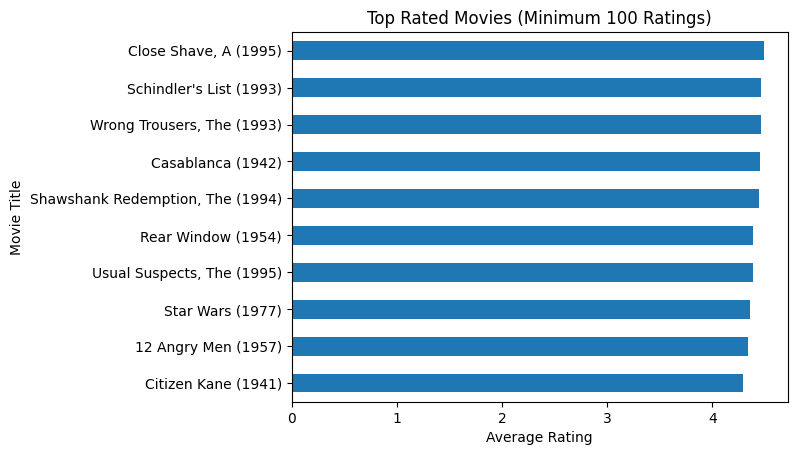

In [45]:
plt.figure(figsize=(12,6))

top_rated_movies.head(10).sort_values(
    by="Average_Rating"
).plot(
    kind="barh",
    y="Average_Rating",
    legend=False
)

plt.title("Top Rated Movies (Minimum 100 Ratings)")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")

plt.show()

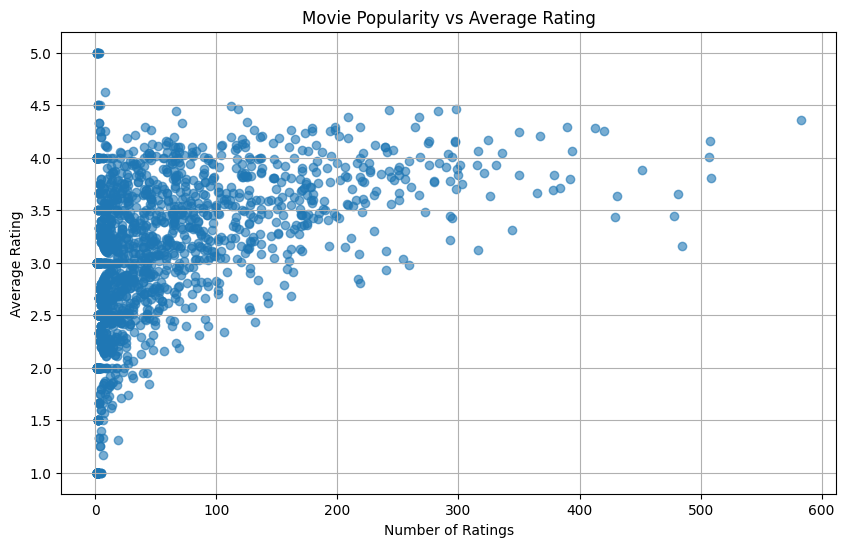

In [46]:
plt.figure(figsize=(10,6))

plt.scatter(
    movie_stats["Number_of_Ratings"],
    movie_stats["Average_Rating"],
    alpha=0.6
)

plt.title("Movie Popularity vs Average Rating")

plt.xlabel("Number of Ratings")

plt.ylabel("Average Rating")

plt.grid(True)

plt.show()

In [47]:
movie_stats.corr(numeric_only=True)

,Average_Rating,Number_of_Ratings
Average_Rating,1.000000,0.430998
Number_of_Ratings,0.430998,1.000000


In [48]:
movie_stats.sort_values(
    by="Number_of_Ratings",
    ascending=False
).head(10)

,Average_Rating,Number_of_Ratings
movie_title,,
Star Wars (1977),4.358491,583
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485
"English Patient, The (1996)",3.656965,481
Scream (1996),3.441423,478
Toy Story (1995),3.878319,452
Air Force One (1997),3.631090,431


## Key Insights from Movie Analysis

- Popularity and average rating are different concepts.
- Movies with very few ratings can have misleadingly high average ratings.
- Applying a minimum rating threshold produces more reliable rankings.
- Recommendation systems should balance popularity and user satisfaction instead of relying on average ratings alone.

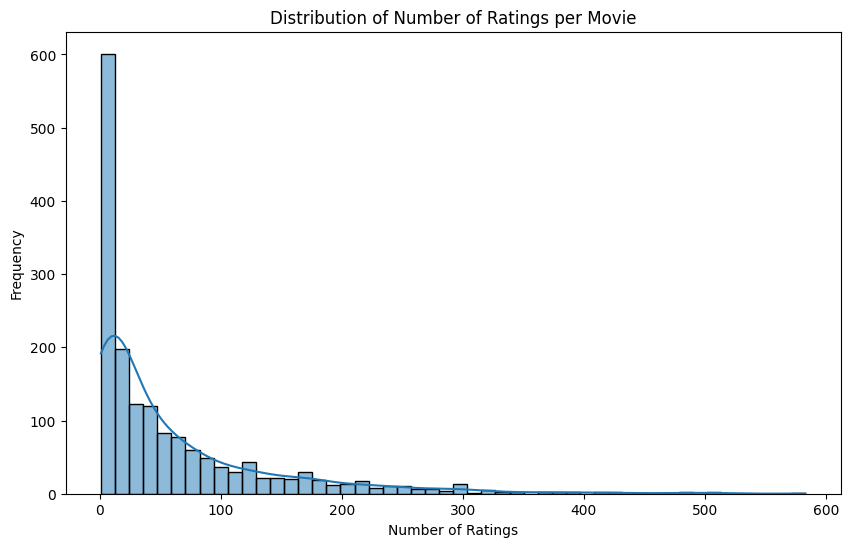

In [49]:
plt.figure(figsize=(10,6))

sns.histplot(
    movie_stats["Number_of_Ratings"],
    bins=50,
    kde=True
)

plt.title("Distribution of Number of Ratings per Movie")

plt.xlabel("Number of Ratings")

plt.ylabel("Frequency")

plt.show()

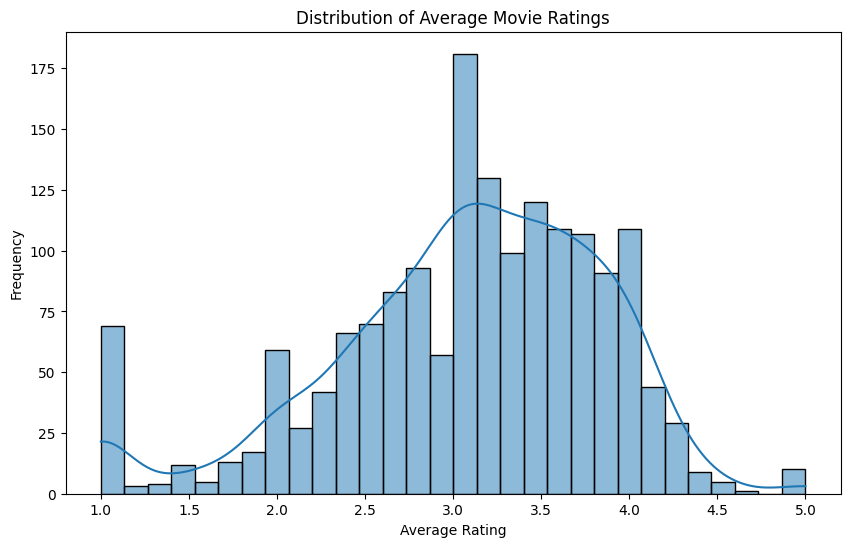

In [50]:
plt.figure(figsize=(10,6))

sns.histplot(
    movie_stats["Average_Rating"],
    bins=30,
    kde=True
)

plt.title("Distribution of Average Movie Ratings")

plt.xlabel("Average Rating")

plt.ylabel("Frequency")

plt.show()

In [51]:
single_rating_movies = movie_stats[
    movie_stats["Number_of_Ratings"] == 1
]

print("Movies with only one rating:", len(single_rating_movies))

single_rating_movies.head(10)

Movies with only one rating: 134


,Average_Rating,Number_of_Ratings
movie_title,,
Aiqing wansui (1994),5.0,1
All Things Fair (1996),3.0,1
Angel on My Shoulder (1946),2.0,1
Angela (1995),3.0,1
August (1996),1.0,1
B. Monkey (1998),3.0,1
Baton Rouge (1988),1.0,1
"Big Bang Theory, The (1994)",4.0,1
"Big One, The (1997)",3.0,1


In [52]:
movie_stats[
    movie_stats["Number_of_Ratings"] >= 300
].sort_values(
    by="Average_Rating",
    ascending=False
)

,Average_Rating,Number_of_Ratings
movie_title,,
Star Wars (1977),4.358491,583
"Silence of the Lambs, The (1991)",4.289744,390
"Godfather, The (1972)",4.283293,413
Raiders of the Lost Ark (1981),4.252381,420
Titanic (1997),4.245714,350
"Empire Strikes Back, The (1980)",4.204360,367
"Princess Bride, The (1987)",4.172840,324
Fargo (1996),4.155512,508
Monty Python and the Holy Grail (1974),4.066456,316


## Final EDA Observations

- The dataset exhibits a long-tail distribution: a small number of movies receive many ratings, while most movies receive very few.
- Average ratings alone are insufficient for ranking because movies with only one or two ratings can appear artificially perfect.
- Combining rating count with average rating provides a more reliable estimate of movie quality.
- These insights motivate the use of popularity thresholds and personalized recommendation algorithms in later stages of the project.

## Final Observations

- The MovieLens dataset contains many movies with very few ratings.
- Around 134 movies have received only a single rating, making their average ratings unreliable.
- Movies with a large number of ratings provide more trustworthy estimates of user satisfaction.
- Therefore, recommendation systems should consider both **rating quality** (average rating) and **rating quantity** (number of ratings).
- These findings justify the use of popularity thresholds before generating recommendations.